# 05 — Realized Variance and Trailing Relative VRP v0.1

This notebook builds the first SPX realized-variance and trailing relative VRP panel.

Primary signal going forward:

```text
log(implied variance / trailing realized variance)
```

SPX 14-day RSI is added as a market-state feature. Forward realized variance is retained only as an audit/ex-post field and is not used in the main signal workflow.


In [1]:
# ============================================================
# Setup
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if current_dir.name.lower() == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
EXTERNAL_DATA_DIR = DATA_DIR / "external"
AUDIT_DIR = DATA_DIR / "audit"

EXTERNAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_TENOR_DAYS = [9, 12, 15, 18, 21, 24, 27, 30, 33]

IMPLIED_PARQUET = PROCESSED_DATA_DIR / "vix_term_structure_history_v0_7_1_repaired_total_variance.parquet"

SPX_FRED_CSV = EXTERNAL_DATA_DIR / "spx_index_daily_fred.csv"
SPX_FRED_NORMALIZED_CSV = EXTERNAL_DATA_DIR / "spx_index_daily_fred_normalized.csv"

REALIZED_PANEL_CSV = PROCESSED_DATA_DIR / "realized_variance_panel_v0_1.csv"
REALIZED_PANEL_PARQUET = PROCESSED_DATA_DIR / "realized_variance_panel_v0_1.parquet"

VRP_PANEL_CSV = PROCESSED_DATA_DIR / "vrp_panel_v0_1.csv"
VRP_PANEL_PARQUET = PROCESSED_DATA_DIR / "vrp_panel_v0_1.parquet"

print("Project root:", PROJECT_ROOT)
print("Implied file exists:", IMPLIED_PARQUET.exists())
print("FRED SPX file exists:", SPX_FRED_CSV.exists())


Project root: C:\Users\patri\vrp_project
Implied file exists: True
FRED SPX file exists: True


## Load and normalize SPX daily closes

The SPX close file is saved locally so the research panel is reproducible. Set `force_refresh_fred_spx = True` only when you intentionally want to refresh the local SPX history.


In [2]:
# ============================================================
# Load / refresh SPX daily closes from FRED
# ============================================================

FRED_SP500_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=SP500"

force_refresh_fred_spx = False

if SPX_FRED_CSV.exists() and not force_refresh_fred_spx:
    spx_raw_df = pd.read_csv(SPX_FRED_CSV)
else:
    spx_raw_df = pd.read_csv(FRED_SP500_URL)
    spx_raw_df.to_csv(SPX_FRED_CSV, index=False)

print("Saved/read FRED SPX file:", SPX_FRED_CSV)
display(spx_raw_df.head())
display(spx_raw_df.tail())


Saved/read FRED SPX file: C:\Users\patri\vrp_project\data\external\spx_index_daily_fred.csv


,observation_date,SP500
0,2016-06-27,2000.54
1,2016-06-28,2036.09
2,2016-06-29,2070.77
3,2016-06-30,2098.86
4,2016-07-01,2102.95


,observation_date,SP500
2605,2026-06-22,7472.79
2606,2026-06-23,7365.46
2607,2026-06-24,7358.22
2608,2026-06-25,7357.49
2609,2026-06-26,7354.02


In [3]:
# ============================================================
# Normalize SPX close file
# ============================================================

spx_df = spx_raw_df.copy()
spx_df.columns = [str(c).strip() for c in spx_df.columns]

date_col = "observation_date" if "observation_date" in spx_df.columns else "DATE"
price_col = "SP500"

if price_col not in spx_df.columns:
    raise ValueError(f"Could not find SP500 column. Columns: {list(spx_df.columns)}")

spx_df["date"] = pd.to_datetime(spx_df[date_col])
spx_df["trade_date"] = spx_df["date"].dt.strftime("%Y%m%d").astype(int)
spx_df["spx_close"] = pd.to_numeric(spx_df[price_col], errors="coerce")

spx_df = (
    spx_df[["trade_date", "date", "spx_close"]]
    .dropna()
    .drop_duplicates("trade_date")
    .sort_values("trade_date")
    .reset_index(drop=True)
)

spx_df["spx_log_return"] = np.log(spx_df["spx_close"] / spx_df["spx_close"].shift(1))

spx_df.to_csv(SPX_FRED_NORMALIZED_CSV, index=False)

print("Rows:", len(spx_df))
print("Date range:", spx_df["trade_date"].min(), "to", spx_df["trade_date"].max())
print("Missing closes:", spx_df["spx_close"].isna().sum())
print("Missing returns:", spx_df["spx_log_return"].isna().sum())
print("Saved normalized SPX file:", SPX_FRED_NORMALIZED_CSV)

display(spx_df.head())
display(spx_df.tail())


Rows: 2514
Date range: 20160627 to 20260626
Missing closes: 0
Missing returns: 1
Saved normalized SPX file: C:\Users\patri\vrp_project\data\external\spx_index_daily_fred_normalized.csv


,trade_date,date,spx_close,spx_log_return
0,20160627,2016-06-27,2000.54,NaN
1,20160628,2016-06-28,2036.09,0.017614
2,20160629,2016-06-29,2070.77,0.016889
3,20160630,2016-06-30,2098.86,0.013474
4,20160701,2016-07-01,2102.95,0.001947


,trade_date,date,spx_close,spx_log_return
2509,20260622,2026-06-22,7472.79,-0.003712
2510,20260623,2026-06-23,7365.46,-0.014467
2511,20260624,2026-06-24,7358.22,-0.000983
2512,20260625,2026-06-25,7357.49,-0.000099
2513,20260626,2026-06-26,7354.02,-0.000472


## Load implied term structure

The implied-vol file should be the repaired v0.7.1 total-variance dataset.


In [4]:
# ============================================================
# Load implied term structure and check SPX close coverage
# ============================================================

implied_df = pd.read_parquet(IMPLIED_PARQUET).copy()

print("Implied rows:", len(implied_df))
print("Implied date range:", implied_df["trade_date"].min(), "to", implied_df["trade_date"].max())

implied_dates = sorted(implied_df["trade_date"].unique())
spx_dates = set(spx_df["trade_date"])

missing_spx_dates = [d for d in implied_dates if d not in spx_dates]

print("Unique implied dates:", len(implied_dates))
print("Missing SPX close dates:", len(missing_spx_dates))

if missing_spx_dates:
    print("First missing dates:")
    print(missing_spx_dates[:20])


Implied rows: 18099
Implied date range: 20180625 to 20260625
Unique implied dates: 2011
Missing SPX close dates: 0


## Realized variance

Tenors are calendar-day horizons. Return observations are trading-day close-to-close log returns that fall inside each calendar window.

For trailing realized variance on trade date `t` and tenor `N`:

```text
use return dates > t - N calendar days and <= t
annualized realized variance = sum(log returns squared) / (N / 365)
```


In [5]:
# ============================================================
# Calendar-day realized variance helper
# ============================================================

def realized_variance_over_calendar_window(
    returns_df,
    trade_date,
    tenor_days,
    direction,
):
    """
    Compute annualized realized variance over a calendar-day window.

    direction = "trailing":
        uses returns with return dates > trade_date - tenor_days
        and <= trade_date.

    direction = "forward":
        uses returns with return dates > trade_date
        and <= trade_date + tenor_days.

    Annualization uses calendar time:
        RV = sum(log_return^2) / (tenor_days / 365)

    Forward RV is audit-only in this project. It is returned as NaN
    when the full forward calendar window is not available.
    """
    trade_ts = pd.to_datetime(str(int(trade_date)), format="%Y%m%d")
    tenor_days = int(tenor_days)

    min_available_date = returns_df["date"].min()
    max_available_date = returns_df["date"].max()

    if direction == "trailing":
        start_ts = trade_ts - pd.Timedelta(days=tenor_days)
        end_ts = trade_ts
        is_complete = start_ts >= min_available_date

        window = returns_df[
            (returns_df["date"] > start_ts)
            & (returns_df["date"] <= end_ts)
        ].copy()

    elif direction == "forward":
        start_ts = trade_ts
        end_ts = trade_ts + pd.Timedelta(days=tenor_days)
        is_complete = end_ts <= max_available_date

        window = returns_df[
            (returns_df["date"] > start_ts)
            & (returns_df["date"] <= end_ts)
        ].copy()

    else:
        raise ValueError("direction must be 'trailing' or 'forward'")

    clean_returns = window["spx_log_return"].dropna()
    num_returns = clean_returns.shape[0]

    if (not is_complete) or num_returns == 0:
        annualized_variance = np.nan
        annualized_vol = np.nan
    else:
        squared_return_sum = np.square(clean_returns).sum()
        annualized_variance = squared_return_sum / (tenor_days / 365.0)
        annualized_vol = np.sqrt(annualized_variance) * 100

    return {
        "realized_variance": annualized_variance,
        "realized_vol": annualized_vol,
        "realized_num_returns": num_returns,
        "realized_window_complete": is_complete,
    }


In [6]:
# ============================================================
# Build realized variance panel
# ============================================================

rv_rows = []

for i, trade_date in enumerate(implied_dates, start=1):
    if i % 250 == 0:
        print(f"Processing {i}/{len(implied_dates)}: {trade_date}")

    for tenor in TARGET_TENOR_DAYS:
        trailing = realized_variance_over_calendar_window(
            returns_df=spx_df,
            trade_date=trade_date,
            tenor_days=tenor,
            direction="trailing",
        )

        # Audit/ex-post field only. Not used in the main signal workflow.
        forward = realized_variance_over_calendar_window(
            returns_df=spx_df,
            trade_date=trade_date,
            tenor_days=tenor,
            direction="forward",
        )

        rv_rows.append({
            "trade_date": trade_date,
            "target_days": tenor,

            "trailing_realized_variance": trailing["realized_variance"],
            "trailing_realized_vol": trailing["realized_vol"],
            "trailing_realized_num_returns": trailing["realized_num_returns"],
            "trailing_realized_window_complete": trailing["realized_window_complete"],

            "forward_realized_variance": forward["realized_variance"],
            "forward_realized_vol": forward["realized_vol"],
            "forward_realized_num_returns": forward["realized_num_returns"],
            "forward_realized_window_complete": forward["realized_window_complete"],
        })

realized_df = pd.DataFrame(rv_rows)

print("Realized rows:", len(realized_df))
print("Expected rows:", len(implied_dates) * len(TARGET_TENOR_DAYS))
print("Missing trailing RV:", realized_df["trailing_realized_variance"].isna().sum())
print("Incomplete trailing windows:", (~realized_df["trailing_realized_window_complete"]).sum())
print("Missing forward RV audit fields:", realized_df["forward_realized_variance"].isna().sum())

display(realized_df.head())
display(realized_df.tail())


Processing 250/2011: 20190621
Processing 500/2011: 20200618
Processing 750/2011: 20210616
Processing 1000/2011: 20220613
Processing 1250/2011: 20230612
Processing 1500/2011: 20240610
Processing 1750/2011: 20250610
Processing 2000/2011: 20260609
Realized rows: 18099
Expected rows: 18099
Missing trailing RV: 0
Incomplete trailing windows: 0
Missing forward RV audit fields: 123


,trade_date,target_days,trailing_realized_variance,trailing_realized_vol,trailing_realized_num_returns,trailing_realized_window_complete,forward_realized_variance,forward_realized_vol,forward_realized_num_returns,forward_realized_window_complete
0,20180625,9,0.010491,10.242504,6,True,0.006165,7.851987,6,True
1,20180625,12,0.008085,8.991663,8,True,0.009035,9.505109,8,True
2,20180625,15,0.006966,8.346020,11,True,0.009398,9.694309,10,True
3,20180625,18,0.006002,7.747385,12,True,0.010422,10.208696,13,True
4,20180625,21,0.006427,8.016921,15,True,0.008951,9.461139,14,True


,trade_date,target_days,trailing_realized_variance,trailing_realized_vol,trailing_realized_num_returns,trailing_realized_window_complete,forward_realized_variance,forward_realized_vol,forward_realized_num_returns,forward_realized_window_complete
18094,20260625,21,0.036819,19.188272,14,True,NaN,NaN,1,False
18095,20260625,24,0.033324,18.254779,17,True,NaN,NaN,1,False
18096,20260625,27,0.029714,17.237747,18,True,NaN,NaN,1,False
18097,20260625,30,0.027201,16.492630,21,True,NaN,NaN,1,False
18098,20260625,33,0.025138,15.854990,22,True,NaN,NaN,1,False


## Build trailing relative VRP panel

Primary signal:

```text
primary_vrp_signal = log(implied variance / trailing realized variance)
```

The raw vol ratio is also saved because it is easier to read as `VIX / RV`.


In [7]:
# ============================================================
# Build VRP panel
# ============================================================

vrp_df = implied_df.merge(
    realized_df,
    on=["trade_date", "target_days"],
    how="left",
    validate="one_to_one",
)

# Absolute trailing VRP fields retained as secondary references.
vrp_df["vrp_trailing_variance"] = (
    vrp_df["implied_variance"] - vrp_df["trailing_realized_variance"]
)

vrp_df["vrp_trailing_vol_points"] = (
    vrp_df["vix_style_vol"] - vrp_df["trailing_realized_vol"]
)

# Relative trailing VRP fields. These are the main signal fields.
vrp_df["vrp_trailing_variance_ratio"] = (
    vrp_df["implied_variance"]
    / vrp_df["trailing_realized_variance"].replace(0, np.nan)
)

vrp_df["vrp_trailing_log_variance_ratio"] = np.log(
    vrp_df["vrp_trailing_variance_ratio"]
)

vrp_df["vrp_trailing_vol_ratio"] = (
    vrp_df["vix_style_vol"]
    / vrp_df["trailing_realized_vol"].replace(0, np.nan)
)

vrp_df["primary_vrp_signal"] = vrp_df["vrp_trailing_log_variance_ratio"]

# Audit/ex-post fields only.
vrp_df["vrp_forward_variance"] = (
    vrp_df["implied_variance"] - vrp_df["forward_realized_variance"]
)

vrp_df["vrp_forward_vol_points"] = (
    vrp_df["vix_style_vol"] - vrp_df["forward_realized_vol"]
)

# Clean impossible/infinite values.
cols_to_clean = [
    "vrp_trailing_variance_ratio",
    "vrp_trailing_log_variance_ratio",
    "vrp_trailing_vol_ratio",
    "primary_vrp_signal",
]

for col in cols_to_clean:
    vrp_df[col] = vrp_df[col].replace([np.inf, -np.inf], np.nan)

print("VRP rows:", len(vrp_df))
print("Missing trailing RV:", vrp_df["trailing_realized_variance"].isna().sum())
print("Missing primary signal:", vrp_df["primary_vrp_signal"].isna().sum())

display(
    vrp_df[
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_variance_ratio",
            "vrp_trailing_log_variance_ratio",
            "vrp_trailing_vol_ratio",
            "primary_vrp_signal",
        ]
    ].head(20)
)


VRP rows: 18099
Missing trailing RV: 0
Missing primary signal: 0


,trade_date,target_days,vix_style_vol,trailing_realized_vol,vrp_trailing_variance_ratio,vrp_trailing_log_variance_ratio,vrp_trailing_vol_ratio,primary_vrp_signal
0,20180625,9,17.348587,10.242504,2.868903,1.053930,1.693784,1.053930
1,20180625,12,17.490509,8.991663,3.783771,1.330721,1.945192,1.330721
2,20180625,15,17.490890,8.346020,4.392027,1.479791,2.095716,1.479791
3,20180625,18,17.491144,7.747385,5.097135,1.628679,2.257684,1.628679
4,20180625,21,17.426522,8.016921,4.725048,1.552878,2.173718,1.552878
5,20180625,24,17.377898,7.699049,5.094720,1.628205,2.257149,1.628205
6,20180625,27,17.349740,9.817784,3.122907,1.138764,1.767175,1.138764
7,20180625,30,17.330003,10.159268,2.909862,1.068106,1.705832,1.068106
8,20180625,33,17.335065,9.741543,3.166617,1.152664,1.779499,1.152664
9,20180626,9,15.359305,10.338066,2.207316,0.791777,1.485704,0.791777


## Add SPX 14-day RSI

RSI is a market-state feature, so it is calculated once per SPX trade date and joined to every tenor row for that date.


In [8]:
# ============================================================
# Add 14-day SPX RSI using Wilder's smoothing
# ============================================================

def calculate_wilder_rsi(price_series, window=14):
    """
    Standard Wilder RSI over trading observations.
    window=14 means 14 trading days.
    """
    delta = price_series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))

    # Edge cases: all gains or no movement.
    rsi = rsi.mask((avg_loss == 0) & (avg_gain > 0), 100)
    rsi = rsi.mask((avg_loss == 0) & (avg_gain == 0), 50)

    return rsi


spx_feature_df = spx_df.copy()

spx_feature_df["spx_rsi_14"] = calculate_wilder_rsi(
    spx_feature_df["spx_close"],
    window=14,
)

spx_feature_df = spx_feature_df[
    [
        "trade_date",
        "spx_close",
        "spx_log_return",
        "spx_rsi_14",
    ]
]

# Drop existing feature columns before joining, so the cell is rerunnable.
feature_cols = ["spx_close", "spx_log_return", "spx_rsi_14"]
vrp_df = vrp_df.drop(columns=[c for c in feature_cols if c in vrp_df.columns])

vrp_df = vrp_df.merge(
    spx_feature_df,
    on="trade_date",
    how="left",
    validate="many_to_one",
)

print("Rows:", len(vrp_df))
print("Missing SPX close:", vrp_df["spx_close"].isna().sum())
print("Missing SPX RSI 14:", vrp_df["spx_rsi_14"].isna().sum())

display(
    vrp_df[
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_log_variance_ratio",
            "spx_close",
            "spx_rsi_14",
        ]
    ].head(20)
)


Rows: 18099
Missing SPX close: 0
Missing SPX RSI 14: 0


,trade_date,target_days,vix_style_vol,trailing_realized_vol,vrp_trailing_log_variance_ratio,spx_close,spx_rsi_14
0,20180625,9,17.348587,10.242504,1.053930,2717.07,41.761584
1,20180625,12,17.490509,8.991663,1.330721,2717.07,41.761584
2,20180625,15,17.490890,8.346020,1.479791,2717.07,41.761584
3,20180625,18,17.491144,7.747385,1.628679,2717.07,41.761584
4,20180625,21,17.426522,8.016921,1.552878,2717.07,41.761584
5,20180625,24,17.377898,7.699049,1.628205,2717.07,41.761584
6,20180625,27,17.349740,9.817784,1.138764,2717.07,41.761584
7,20180625,30,17.330003,10.159268,1.068106,2717.07,41.761584
8,20180625,33,17.335065,9.741543,1.152664,2717.07,41.761584
9,20180626,9,15.359305,10.338066,0.791777,2723.06,43.759005


## Validation checks


In [9]:
# ============================================================
# Validate panel structure and missing values
# ============================================================

print("VRP rows:", len(vrp_df))
print("Date range:", vrp_df["trade_date"].min(), "to", vrp_df["trade_date"].max())

print("\nRows by tenor:")
display(vrp_df["target_days"].value_counts().sort_index())

duplicate_check = (
    vrp_df
    .groupby(["trade_date", "target_days"])
    .size()
    .reset_index(name="count")
)

duplicates = duplicate_check[duplicate_check["count"] > 1]

print("\nDuplicate date/tenor rows:", len(duplicates))
if len(duplicates) > 0:
    display(duplicates)

missing_cols = [
    "implied_variance",
    "vix_style_vol",
    "trailing_realized_variance",
    "trailing_realized_vol",
    "vrp_trailing_variance_ratio",
    "vrp_trailing_log_variance_ratio",
    "vrp_trailing_vol_ratio",
    "primary_vrp_signal",
    "spx_close",
    "spx_log_return",
    "spx_rsi_14",
]

print("\nMissing values:")
display(vrp_df[missing_cols].isna().sum())


VRP rows: 18099
Date range: 20180625 to 20260625

Rows by tenor:


target_days
9     2011
12    2011
15    2011
18    2011
21    2011
24    2011
27    2011
30    2011
33    2011
Name: count, dtype: int64


Duplicate date/tenor rows: 0

Missing values:


implied_variance                   0
vix_style_vol                      0
trailing_realized_variance         0
trailing_realized_vol              0
vrp_trailing_variance_ratio        0
vrp_trailing_log_variance_ratio    0
vrp_trailing_vol_ratio             0
primary_vrp_signal                 0
spx_close                          0
spx_log_return                     0
spx_rsi_14                         0
dtype: int64

In [10]:
# ============================================================
# Realized return-count sanity check
# ============================================================

print("Trailing realized return counts by tenor:")
display(
    vrp_df
    .groupby("target_days")["trailing_realized_num_returns"]
    .describe()
)

print("Trailing window completeness by tenor:")
display(
    vrp_df
    .groupby("target_days")["trailing_realized_window_complete"]
    .mean()
)


Trailing realized return counts by tenor:


,count,mean,std,min,25%,50%,75%,max
target_days,,,,,,,,
9,2011.0,6.590751,0.568750,5.0,6.0,7.0,7.0,7.0
12,2011.0,8.294878,0.915901,6.0,8.0,8.0,9.0,10.0
15,2011.0,10.621581,0.527372,9.0,10.0,11.0,11.0,11.0
18,2011.0,12.546494,1.049616,10.0,12.0,13.0,13.0,14.0
21,2011.0,14.473396,0.600715,12.0,14.0,15.0,15.0,15.0
24,2011.0,16.798608,1.005318,13.0,16.0,17.0,18.0,18.0
27,2011.0,18.506713,0.765766,16.0,18.0,19.0,19.0,20.0
30,2011.0,21.034809,0.800983,18.0,21.0,21.0,22.0,22.0
33,2011.0,22.738439,1.062808,19.0,22.0,23.0,23.0,25.0


Trailing window completeness by tenor:


target_days
9     1.0
12    1.0
15    1.0
18    1.0
21    1.0
24    1.0
27    1.0
30    1.0
33    1.0
Name: trailing_realized_window_complete, dtype: float64

In [11]:
# ============================================================
# Trailing relative VRP summary by tenor
# ============================================================

trailing_summary_cols = [
    "vix_style_vol",
    "trailing_realized_vol",
    "vrp_trailing_variance_ratio",
    "vrp_trailing_log_variance_ratio",
    "vrp_trailing_vol_ratio",
    "primary_vrp_signal",
    "spx_rsi_14",
]

trailing_vrp_summary_by_tenor = (
    vrp_df
    .groupby("target_days")[trailing_summary_cols]
    .agg(["mean", "median", "std", "min", "max"])
)

display(trailing_vrp_summary_by_tenor)


vix_style_vol                                              \
                     mean     median       std        min         max   
target_days                                                             
9               19.076065  16.727018  9.070484   8.588728  107.055162   
12              19.231810  16.940567  8.618185   9.325364  101.849588   
15              19.356858  17.146458  8.296850   9.686847   96.636522   
18              19.483665  17.409845  8.006853   9.996208   92.998942   
21              19.596325  17.623429  7.764366  10.243030   89.289969   
24              19.706569  17.802560  7.568364  10.413069   86.403820   
27              19.824019  17.936999  7.411386  10.523656   83.129795   
30              19.933814  18.074118  7.304011  10.611297   80.414657   
33              20.047058  18.223110  7.211770  10.898647   79.274362   

            trailing_realized_vol                                              \
                             mean     median        std       min         max   
target_days                                                                     
9                       16.062037  13.165230  12.298622  1.947321  140.448482   
12                      15.696870  12.968432  11.802929  3.325238  127.515877   
15                      16.074684  13.268207  11.632945  4.255583  116.882163   
18                      16.004172  13.248752  11.411442  4.421850  115.846315   
21                      16.037640  13.280972  11.203157  4.525211  108.200160   
24                      16.220314  13.550390  11.177959  5.069283  103.724411   
27                      16.111909  13.418841  10.941151  5.354372   99.606314   
30                      16.364199  13.508815  10.900419  5.434726   96.227205   
33                      16.258730  13.293310  10.759837  5.183680   92.657579   

             ... primary_vrp_signal                                          \
             ...               mean    median       std       min       max   
target_days  ...                                                              
9            ...           0.542956  0.483687  0.718155 -1.669171  3.581716   
12           ...           0.597373  0.561841  0.685056 -1.517302  2.927059   
15           ...           0.548693  0.507251  0.648159 -1.495771  2.854262   
18           ...           0.568096  0.537507  0.638058 -1.372333  2.659418   
21           ...           0.570486  0.542314  0.620504 -1.340360  2.446820   
24           ...           0.556410  0.532688  0.613564 -1.504169  2.442174   
27           ...           0.577328  0.555591  0.602256 -1.511559  2.195524   
30           ...           0.552580  0.519910  0.595305 -1.578182  2.153557   
33           ...           0.576153  0.555169  0.592967 -1.606376  2.153717   

            spx_rsi_14                                              
                  mean     median        std        min        max  
target_days                                                         
9            55.688638  57.414915  11.525885  17.658206  82.900307  
12           55.688638  57.414915  11.525885  17.658206  82.900307  
15           55.688638  57.414915  11.525885  17.658206  82.900307  
18           55.688638  57.414915  11.525885  17.658206  82.900307  
21           55.688638  57.414915  11.525885  17.658206  82.900307  
24           55.688638  57.414915  11.525885  17.658206  82.900307  
27           55.688638  57.414915  11.525885  17.658206  82.900307  
30           55.688638  57.414915  11.525885  17.658206  82.900307  
33           55.688638  57.414915  11.525885  17.658206  82.900307  

[9 rows x 35 columns]

## Quick plots

These are sanity plots only. The z-score and signal work begins in notebook 06.


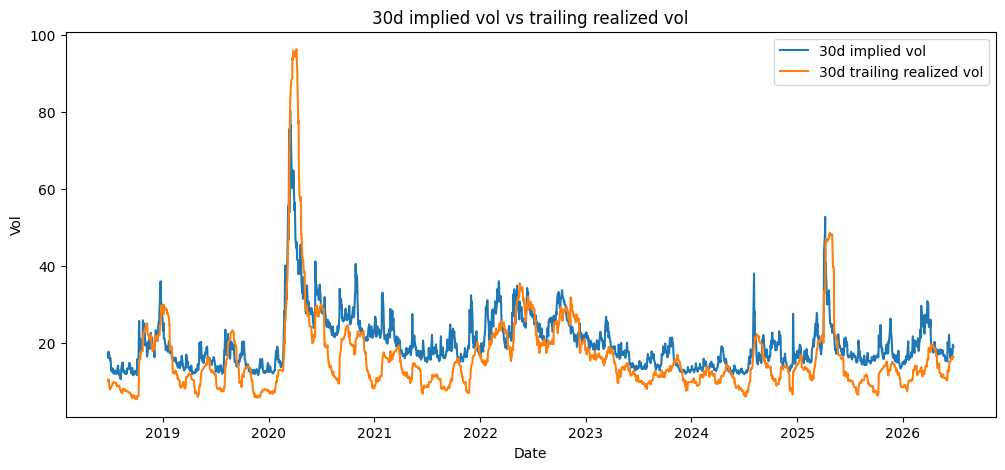

In [12]:
# ============================================================
# Plot 30d implied vol vs trailing realized vol
# ============================================================

plot_30d_df = vrp_df[vrp_df["target_days"] == 30].copy()
plot_30d_df["date"] = pd.to_datetime(plot_30d_df["trade_date"].astype(str))

plt.figure(figsize=(12, 5))
plt.plot(plot_30d_df["date"], plot_30d_df["vix_style_vol"], label="30d implied vol")
plt.plot(plot_30d_df["date"], plot_30d_df["trailing_realized_vol"], label="30d trailing realized vol")
plt.title("30d implied vol vs trailing realized vol")
plt.xlabel("Date")
plt.ylabel("Vol")
plt.legend()
plt.show()


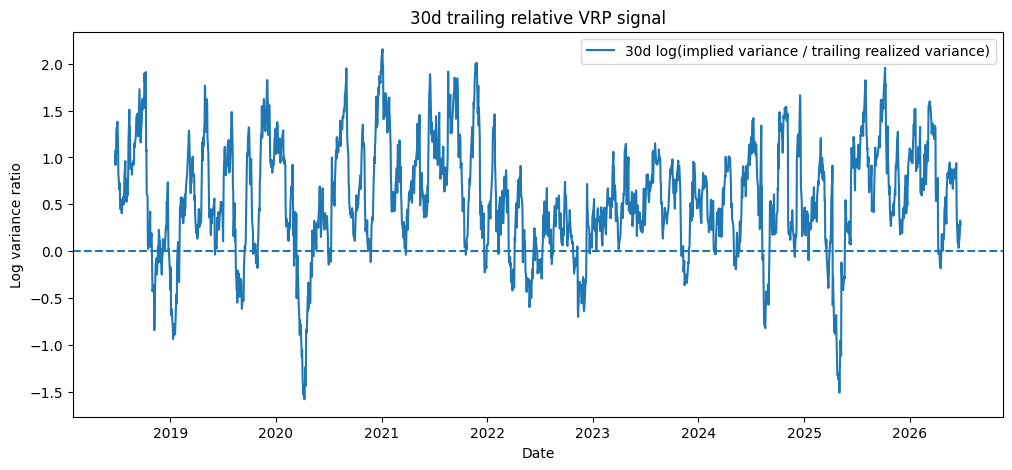

In [13]:
# ============================================================
# Plot 30d trailing relative VRP signal
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(
    plot_30d_df["date"],
    plot_30d_df["primary_vrp_signal"],
    label="30d log(implied variance / trailing realized variance)",
)
plt.axhline(0, linestyle="--")
plt.title("30d trailing relative VRP signal")
plt.xlabel("Date")
plt.ylabel("Log variance ratio")
plt.legend()
plt.show()


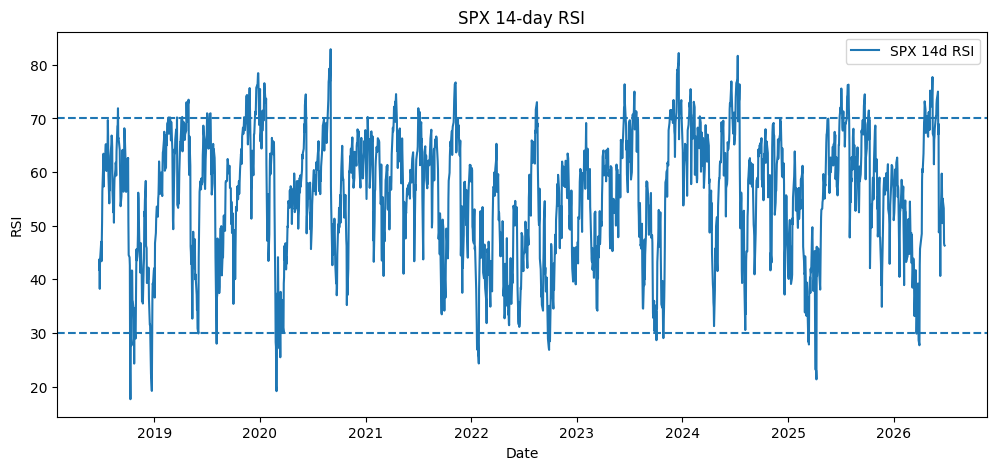

In [14]:
# ============================================================
# Plot SPX 14-day RSI
# ============================================================

rsi_by_date = (
    vrp_df[["trade_date", "spx_close", "spx_rsi_14"]]
    .drop_duplicates("trade_date")
    .sort_values("trade_date")
    .copy()
)

rsi_by_date["date"] = pd.to_datetime(rsi_by_date["trade_date"].astype(str))

plt.figure(figsize=(12, 5))
plt.plot(rsi_by_date["date"], rsi_by_date["spx_rsi_14"], label="SPX 14d RSI")
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.title("SPX 14-day RSI")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.show()


## Save final panels


In [15]:
# ============================================================
# Save realized variance and VRP panels
# ============================================================

realized_df.to_csv(REALIZED_PANEL_CSV, index=False)
realized_df.to_parquet(REALIZED_PANEL_PARQUET, index=False)

vrp_df.to_csv(VRP_PANEL_CSV, index=False)
vrp_df.to_parquet(VRP_PANEL_PARQUET, index=False)

print("Saved realized CSV:", REALIZED_PANEL_CSV)
print("Saved realized parquet:", REALIZED_PANEL_PARQUET)
print("Saved VRP CSV:", VRP_PANEL_CSV)
print("Saved VRP parquet:", VRP_PANEL_PARQUET)

print("\nRows:", len(vrp_df))
print("Primary signal column: primary_vrp_signal")
print("RSI column: spx_rsi_14")


Saved realized CSV: C:\Users\patri\vrp_project\data\processed\realized_variance_panel_v0_1.csv
Saved realized parquet: C:\Users\patri\vrp_project\data\processed\realized_variance_panel_v0_1.parquet
Saved VRP CSV: C:\Users\patri\vrp_project\data\processed\vrp_panel_v0_1.csv
Saved VRP parquet: C:\Users\patri\vrp_project\data\processed\vrp_panel_v0_1.parquet

Rows: 18099
Primary signal column: primary_vrp_signal
RSI column: spx_rsi_14


In [16]:
# ============================================================
# Final column check
# ============================================================

important_columns = [
    "trade_date",
    "target_days",
    "vix_style_vol",
    "implied_variance",
    "trailing_realized_vol",
    "trailing_realized_variance",
    "vrp_trailing_variance_ratio",
    "vrp_trailing_log_variance_ratio",
    "vrp_trailing_vol_ratio",
    "primary_vrp_signal",
    "spx_close",
    "spx_log_return",
    "spx_rsi_14",
]

print("Important columns present:")
for col in important_columns:
    print(f"{col}: {col in vrp_df.columns}")

display(vrp_df[important_columns].tail(30))


Important columns present:
trade_date: True
target_days: True
vix_style_vol: True
implied_variance: True
trailing_realized_vol: True
trailing_realized_variance: True
vrp_trailing_variance_ratio: True
vrp_trailing_log_variance_ratio: True
vrp_trailing_vol_ratio: True
primary_vrp_signal: True
spx_close: True
spx_log_return: True
spx_rsi_14: True


,trade_date,target_days,vix_style_vol,implied_variance,trailing_realized_vol,trailing_realized_variance,vrp_trailing_variance_ratio,vrp_trailing_log_variance_ratio,vrp_trailing_vol_ratio,primary_vrp_signal,spx_close,spx_log_return,spx_rsi_14
18069,20260622,27,17.159877,0.029446,16.547043,0.027380,1.075443,0.072733,1.037036,0.072733,7472.79,-0.003712,53.235432
18070,20260622,30,17.318125,0.029992,15.840962,0.025094,1.195195,0.178309,1.093250,0.178309,7472.79,-0.003712,53.235432
18071,20260622,33,17.502016,0.030632,15.165067,0.022998,1.331949,0.286643,1.154101,0.286643,7472.79,-0.003712,53.235432
18072,20260623,9,19.652659,0.038623,17.900259,0.032042,1.205380,0.186795,1.097898,0.186795,7365.46,-0.014467,46.752076
18073,20260623,12,19.402357,0.037645,15.746680,0.024796,1.518207,0.417530,1.232155,0.417530,7365.46,-0.014467,46.752076
18074,20260623,15,19.250614,0.037059,18.392573,0.033829,1.095479,0.091192,1.046651,0.091192,7365.46,-0.014467,46.752076
18075,20260623,18,19.231723,0.036986,16.843361,0.028370,1.303704,0.265209,1.141798,0.265209,7365.46,-0.014467,46.752076
18076,20260623,21,19.359673,0.037480,19.503400,0.038038,0.985316,-0.014793,0.992631,-0.014793,7365.46,-0.014467,46.752076
18077,20260623,24,19.455023,0.037850,18.279328,0.033413,1.132773,0.124669,1.064318,0.124669,7365.46,-0.014467,46.752076
18078,20260623,27,19.528330,0.038136,17.380854,0.030209,1.262374,0.232994,1.123554,0.232994,7365.46,-0.014467,46.752076
